In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import torch
import torch.optim as optim
import torch.nn as nn
import torch.nn.functional as F
from sklearn.model_selection import train_test_split

from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import RobustScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.manifold import TSNE
import os

In [2]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device

device(type='cpu')

In [3]:
df=pd.read_csv("pre_final_database.csv")
df.shape

(5529, 37)

In [4]:
df.drop(columns=[#'sub_user',  ##As it has irrelevant data and very weak correlation with other table
                 'live_interview_credit', ##As it har irrelevant data and very weak correlation with other table
                 'pre_recorded_credit',
                 'ai_live_interview_credit',#As it has strong correlation 1
                 'referral_credit'], #has 200,400,600,44000==1 or 2, almost all are 0 and has strong correlation with ai_kit_count of 1
        inplace=True)
df.shape

(5529, 33)

In [5]:
df['company_size'] = pd.Categorical(df['company_size'], categories=['1-25', '26-100', '101-500', '500-1000', 'More than 1000'], ordered=True).codes
df = pd.get_dummies(df, columns=['jobma_catcher_otype', 'per_sub_user'], prefix=['otype', 'subuser'], drop_first=True)

In [6]:
df = df.astype({col: int for col in df.columns if df[col].dtype == 'bool'})
df['sub_user'] = df['sub_user'].apply(lambda x: 1000 if x > 1000 else x)      #To handele extreme outlier

In [7]:
df.shape

(5529, 45)

In [8]:
# Converting df to tensor and Preprocess

In [9]:
X = df.values
scaler = RobustScaler()

In [10]:
X_scaled = scaler.fit_transform(X)
X_tensor = torch.tensor(X_scaled, dtype=torch.float32)
dataset = TensorDataset(X_tensor)
dataloader = DataLoader(dataset, batch_size=64, shuffle=True)

In [11]:
# Autoencoder for robustness
class AutoEncoder(nn.Module):
    def __init__(self, input_dim, hidden_dim=100, latent_dim=10):
        super(AutoEncoder, self).__init__()
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, latent_dim)
        )
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, input_dim)
        )
        

    def forward(self, x):
        z = self.encoder(x)
        x_bar = self.decoder(z)
        return x_bar, z

In [12]:
# Pretraining Autoencoder
input_dim = X_scaled.shape[1]
autoencoder = AutoEncoder(input_dim).to(device)
optimizer = torch.optim.Adam(autoencoder.parameters(), lr=1e-3)
criterion = nn.SmoothL1Loss()  # More robust than MSE with 

In [13]:
#Pretraining Autoencoder
for epoch in range(50):
    autoencoder.train()
    total_loss = 0
    for batch in dataloader:
        x_batch = batch[0].to(device)
        x_bar, _ = autoencoder(x_batch)
        loss = criterion(x_bar, x_batch)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    print(f"[Pretrain] Epoch {epoch+1}, Loss: {total_loss/len(dataloader):.4f}")

[Pretrain] Epoch 1, Loss: 6.0828
[Pretrain] Epoch 2, Loss: 6.0129
[Pretrain] Epoch 3, Loss: 5.9255
[Pretrain] Epoch 4, Loss: 5.6144
[Pretrain] Epoch 5, Loss: 4.6051
[Pretrain] Epoch 6, Loss: 3.4116
[Pretrain] Epoch 7, Loss: 2.9191
[Pretrain] Epoch 8, Loss: 2.5425
[Pretrain] Epoch 9, Loss: 2.3772
[Pretrain] Epoch 10, Loss: 2.2014
[Pretrain] Epoch 11, Loss: 2.1019
[Pretrain] Epoch 12, Loss: 1.2014
[Pretrain] Epoch 13, Loss: 1.3677
[Pretrain] Epoch 14, Loss: 1.1141
[Pretrain] Epoch 15, Loss: 1.3833
[Pretrain] Epoch 16, Loss: 1.5166
[Pretrain] Epoch 17, Loss: 1.2471
[Pretrain] Epoch 18, Loss: 1.2071
[Pretrain] Epoch 19, Loss: 0.9128
[Pretrain] Epoch 20, Loss: 1.0925
[Pretrain] Epoch 21, Loss: 1.2580
[Pretrain] Epoch 22, Loss: 1.0572
[Pretrain] Epoch 23, Loss: 0.8802
[Pretrain] Epoch 24, Loss: 1.3594
[Pretrain] Epoch 25, Loss: 0.9624
[Pretrain] Epoch 26, Loss: 1.3331
[Pretrain] Epoch 27, Loss: 1.2490
[Pretrain] Epoch 28, Loss: 1.0445
[Pretrain] Epoch 29, Loss: 1.4261
[Pretrain] Epoch 30, Lo

In [14]:
# Extract Latent Features
autoencoder.eval()
with torch.no_grad():
    _, latent = autoencoder(X_tensor.to(device))
latent_np = latent.cpu().numpy()

In [15]:
# Determine Optimal Cluster Count   #Finding optimal number of clusters using Silhouette Score
scores = []
K_range = range(2, 15)
for k in K_range:
    kmeans = KMeans(n_clusters=k, n_init=10)
    labels = kmeans.fit_predict(latent_np)
    score = silhouette_score(latent_np, labels)
    scores.append(score)
    print(f"Clusters: {k}, Silhouette Score: {score:.4f}")

Clusters: 2, Silhouette Score: 0.9966
Clusters: 3, Silhouette Score: 0.9687
Clusters: 4, Silhouette Score: 0.9099
Clusters: 5, Silhouette Score: 0.9109
Clusters: 6, Silhouette Score: 0.8981
Clusters: 7, Silhouette Score: 0.8155
Clusters: 8, Silhouette Score: 0.8272
Clusters: 9, Silhouette Score: 0.8759
Clusters: 10, Silhouette Score: 0.8878
Clusters: 11, Silhouette Score: 0.8890
Clusters: 12, Silhouette Score: 0.8907
Clusters: 13, Silhouette Score: 0.8909
Clusters: 14, Silhouette Score: 0.8932


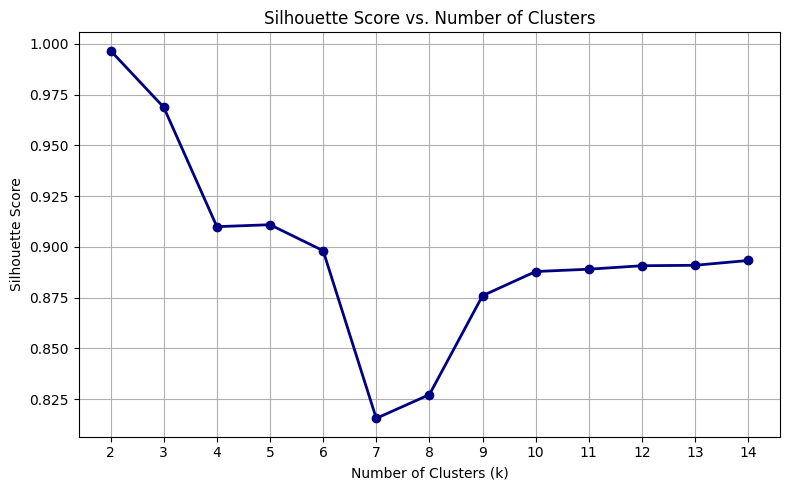

In [16]:
# Plotting
plt.figure(figsize=(8, 5))
plt.plot(K_range, scores, marker='o', color='navy', linewidth=2)
plt.title("Silhouette Score vs. Number of Clusters")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Silhouette Score")
plt.xticks(K_range)
plt.grid(True)
plt.tight_layout()
plt.show()

In [17]:
#Initialising KMeans
kmeans = KMeans(n_clusters=10, n_init=20)
cluster_ids = kmeans.fit_predict(latent_np)
cluster_centers = torch.tensor(kmeans.cluster_centers_, dtype=torch.float32).to(device)

In [18]:
# Deep Embedding Clusturing Model
class DEC(nn.Module):
    def __init__(self, encoder, cluster_centers):
        super(DEC, self).__init__()
        self.encoder = encoder
        self.cluster_centers = nn.Parameter(cluster_centers)

    def forward(self, x):
        z = self.encoder(x)
        q = 1.0 / (1.0 + torch.sum((z.unsqueeze(1) - self.cluster_centers)**2, dim=2))
        q = q.pow((1 + 1) / 2.0)
        q = (q.t() / torch.sum(q, dim=1)).t()
        return q, z

def target_distribution(q):
    weight = q**2 / q.sum(0)
    return (weight.t() / weight.sum(1)).t()  

#Train DEC
dec = DEC(autoencoder.encoder, cluster_centers.clone()).to(device)
optimizer = torch.optim.Adam(dec.parameters(), lr=1e-3)

In [19]:
#Training DEC (with reconstruction loss)

In [20]:
for epoch in range(50):
    dec.train()
    total_loss = 0
    all_q = []

    for batch in dataloader:
        x = batch[0].to(device)
        q, _ = dec(x)
        all_q.append(q.detach().cpu())
    q_all = torch.cat(all_q, dim=0)
    p_all = target_distribution(q_all)

    entropy = -torch.sum(q_all * torch.log(q_all + 1e-10)) / q_all.size(0)

    idx = 0
    for batch in dataloader:
        x = batch[0].to(device)
        q, z = dec(x)
        p = p_all[idx:idx + len(x)].to(device)
        kl_loss = F.kl_div(q.log(), p, reduction='batchmean')
        x_bar = autoencoder.decoder(z)
        recon_loss = F.smooth_l1_loss(x_bar, x)
        loss = kl_loss + 0.1 * recon_loss
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        idx += len(x)
        total_loss += loss.item()

    print(f"[DEC] Epoch {epoch+1}, KL Loss: {total_loss/len(dataloader):.4f}, Entropy: {entropy:.4f}")

[DEC] Epoch 1, KL Loss: 1.5433, Entropy: 0.1080
[DEC] Epoch 2, KL Loss: 1.2251, Entropy: 0.3805
[DEC] Epoch 3, KL Loss: 1.1232, Entropy: 0.4628
[DEC] Epoch 4, KL Loss: 1.0785, Entropy: 0.5215
[DEC] Epoch 5, KL Loss: 1.0044, Entropy: 0.5818
[DEC] Epoch 6, KL Loss: 0.9696, Entropy: 0.6147
[DEC] Epoch 7, KL Loss: 0.9347, Entropy: 0.6709
[DEC] Epoch 8, KL Loss: 0.9237, Entropy: 0.6943
[DEC] Epoch 9, KL Loss: 0.8659, Entropy: 0.7482
[DEC] Epoch 10, KL Loss: 0.8569, Entropy: 0.7793
[DEC] Epoch 11, KL Loss: 0.8339, Entropy: 0.8017
[DEC] Epoch 12, KL Loss: 0.8331, Entropy: 0.8160
[DEC] Epoch 13, KL Loss: 0.8183, Entropy: 0.8401
[DEC] Epoch 14, KL Loss: 0.8021, Entropy: 0.8567
[DEC] Epoch 15, KL Loss: 0.8111, Entropy: 0.8599
[DEC] Epoch 16, KL Loss: 0.7778, Entropy: 0.8812
[DEC] Epoch 17, KL Loss: 0.7907, Entropy: 0.8710
[DEC] Epoch 18, KL Loss: 0.7929, Entropy: 0.8825
[DEC] Epoch 19, KL Loss: 0.7526, Entropy: 0.9157
[DEC] Epoch 20, KL Loss: 0.7636, Entropy: 0.9097
[DEC] Epoch 21, KL Loss: 0.76

In [21]:
#Final Prediction
dec.eval()
with torch.no_grad():
    q, _ = dec(X_tensor.to(device))
    preds = torch.argmax(q, dim=1).cpu().numpy()

df['dec_cluster'] = preds
print("Clustering complete")

Clustering complete


In [22]:
df['dec_cluster'].head(10)

0    4
1    0
2    0
3    0
4    0
5    0
6    0
7    0
8    0
9    0
Name: dec_cluster, dtype: int64

In [23]:
#Visualizing clusters with t-SNE..

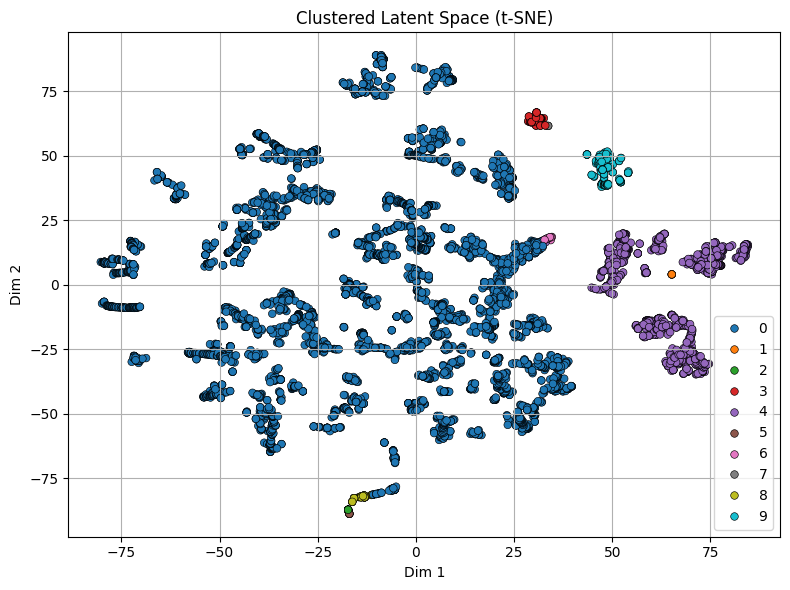

In [24]:
tsne = TSNE(n_components=2, random_state=42)
latent_2d = tsne.fit_transform(latent_np)

plt.figure(figsize=(8, 6))
sns.scatterplot(x=latent_2d[:, 0], y=latent_2d[:, 1], hue=preds, palette='tab10', s=30, edgecolor='k')
plt.title("Clustered Latent Space (t-SNE)")
plt.xlabel("Dim 1")
plt.ylabel("Dim 2")
plt.grid(True)
plt.tight_layout()
plt.show()

In [25]:
sil_score = silhouette_score(latent_np, preds)
print(f"Silhouette Score: {sil_score}")

Silhouette Score: 0.8882034420967102


In [26]:
# Checking the size of each cluster
cluster_sizes = pd.Series(preds).value_counts()
cluster_sizes

0    4475
4     772
9     146
3      55
8      40
2      15
6      14
5       5
1       5
7       2
Name: count, dtype: int64

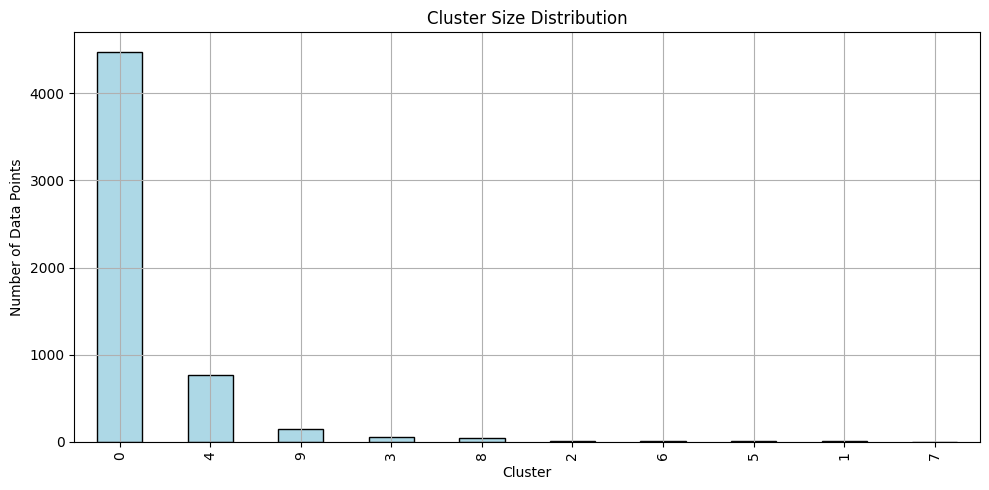

In [27]:
# Visualize the cluster distribution
plt.figure(figsize=(10, 5))
cluster_sizes.plot(kind='bar', color='lightblue', edgecolor='black')
plt.title("Cluster Size Distribution")
plt.xlabel("Cluster")
plt.ylabel("Number of Data Points")
plt.grid(True)
plt.tight_layout()
plt.show()